# 11. Recent-Window Modeling

This notebook tests whether training on only the most recent history improves lotto number modeling stability. It keeps the model family comparison separate from notebook 10 and introduces a new axis: **how much past history to keep during training**.

Notebook 10 already covered full-history training, so this notebook focuses only on shorter recent windows to avoid redundant reruns.

## Bootstrap

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
APP_ROOT = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / "src" / "notebook_support.py").exists() and (candidate / "data").exists():
        APP_ROOT = candidate
        break
    if (candidate / "app" / "src" / "notebook_support.py").exists() and (candidate / "app" / "data").exists():
        APP_ROOT = candidate / "app"
        break

if APP_ROOT is None:
    raise RuntimeError(f"Could not locate app root from {cwd}")

if str(APP_ROOT) not in sys.path:
    sys.path.insert(0, str(APP_ROOT))

from src.notebook_support import describe_notebook_environment
describe_notebook_environment(APP_ROOT)

{'app_root': '/workspace', 'cwd': '/workspace/notebooks'}

## Imports

In [2]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.features import build_model_feature_bundle, describe_feature_sets, load_weather_context
from src.features.temporal_features import time_based_train_test_split
from src.models import (
    build_classifier_chain_model,
    build_logistic_regression_model,
    build_random_forest_model,
    build_scaled_mlp_model,
    build_soft_voting_ensemble_model,
    build_xgboost_model,
)
from src.models.model_suite import evaluate_number_predictions, evaluate_probability_model, probability_matrix_to_number_lists
from src.visualization import save_report_figure, save_report_table

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)
np.random.seed(42)

## Configuration

In [3]:
RUN_MODE = "full"

WINDOW = 20
TEST_RATIO = 0.2
RANDOM_SEED = 42
TRAIN_WINDOW_SIZES = [500, 300, 200]
FEATURE_SET_NAMES = [
    "base",
    "base_plus_pattern",
]

BACKTEST_INITIAL_TRAIN_SIZE = 600
BACKTEST_TEST_SIZE = 30
BACKTEST_STEP_SIZE = 30

if RUN_MODE == "quick":
    MODEL_NAMES = [
        "random_baseline",
        "logistic_regression",
        "soft_voting_ensemble",
    ]
    BACKTEST_MODEL_NAMES = [
        "random_baseline",
        "logistic_regression",
        "soft_voting_ensemble",
    ]
    MAX_BACKTEST_FOLDS = 4
else:
    FEATURE_SET_NAMES = [
        "base",
        "base_plus_pattern",
        "base_plus_context",
        "full_feature_set",
    ]
    MODEL_NAMES = [
        "random_baseline",
        "logistic_regression",
        "xgboost",
        "classifier_chain",
        "soft_voting_ensemble",
        "mlp",
    ]
    BACKTEST_MODEL_NAMES = MODEL_NAMES.copy()
    MAX_BACKTEST_FOLDS = 10

## Load Feature Bundle

In [4]:
weather_df = load_weather_context()
feature_bundle = build_model_feature_bundle(window=WINDOW, save_base=False, weather_df=weather_df)
y = feature_bundle.y.reset_index(drop=True)
LABEL_COLS = y.columns.tolist()
feature_sets = feature_bundle.feature_sets

describe_feature_sets(feature_bundle)

,feature_set,n_features,description
0,base,90,Rolling frequency and gap features only.
1,base_plus_pattern,118,Base features plus draw-level internal pattern...
2,base_plus_context,121,Base features plus calendar and weather context.
3,full_feature_set,149,"Base, internal pattern, and context features c..."


## Recent-Window Helpers

In [5]:
def random_predictions(n_rows: int, seed: int):
    rng = np.random.default_rng(seed)
    return [sorted(rng.choice(np.arange(1, 46), size=6, replace=False).tolist()) for _ in range(n_rows)]


def frequency_heuristic_predictions(X_frame: pd.DataFrame):
    freq_cols = [col for col in X_frame.columns if col.startswith("freq_")]
    return probability_matrix_to_number_lists(X_frame[freq_cols].to_numpy())


def gap_heuristic_predictions(X_frame: pd.DataFrame):
    gap_cols = [col for col in X_frame.columns if col.startswith("gap_")]
    return probability_matrix_to_number_lists(X_frame[gap_cols].to_numpy())


def build_model(model_name: str, random_seed: int):
    if model_name == "logistic_regression":
        return build_logistic_regression_model(random_seed=random_seed)
    if model_name == "random_forest":
        return build_random_forest_model(random_seed=random_seed)
    if model_name == "xgboost":
        return build_xgboost_model(random_seed=random_seed)
    if model_name == "classifier_chain":
        return build_classifier_chain_model(random_seed=random_seed)
    if model_name == "soft_voting_ensemble":
        return build_soft_voting_ensemble_model(random_seed=random_seed)
    if model_name == "mlp":
        return build_scaled_mlp_model(random_seed=random_seed)
    raise ValueError(model_name)


def window_label(train_window_size):
    return "full_history" if train_window_size is None else f"last_{train_window_size}"


def apply_train_window(X_train, y_train, train_window_size):
    if train_window_size is None:
        return X_train.reset_index(drop=True), y_train.reset_index(drop=True)
    return (
        X_train.tail(train_window_size).reset_index(drop=True),
        y_train.tail(train_window_size).reset_index(drop=True),
    )


def evaluate_recent_window_holdout(feature_set_name, model_name, X_frame, y_frame, train_window_size, test_ratio=TEST_RATIO, random_seed=RANDOM_SEED):
    split = time_based_train_test_split(X_frame, y_frame, test_ratio=test_ratio)
    X_train, y_train = apply_train_window(split["X_train"], split["y_train"], train_window_size)
    X_test = split["X_test"].reset_index(drop=True)
    y_test = split["y_test"].reset_index(drop=True)

    if model_name == "freq_heuristic":
        result = evaluate_number_predictions(model_name, frequency_heuristic_predictions(X_test), y_test, label_cols=LABEL_COLS)
    elif model_name == "gap_heuristic":
        result = evaluate_number_predictions(model_name, gap_heuristic_predictions(X_test), y_test, label_cols=LABEL_COLS)
    elif model_name == "random_baseline":
        result = evaluate_number_predictions(model_name, random_predictions(len(X_test), random_seed), y_test, label_cols=LABEL_COLS)
    else:
        model = build_model(model_name, random_seed=random_seed)
        model.fit(X_train, y_train)
        result = evaluate_probability_model(model_name, model, X_test, y_test)

    return {
        "feature_set": feature_set_name,
        "model": model_name,
        "train_window_label": window_label(train_window_size),
        "train_window_size": train_window_size if train_window_size is not None else -1,
        "subset_accuracy": result["subset_accuracy"],
        "number_level_accuracy": result["number_level_accuracy"],
        "avg_hit": result["avg_hit"],
        "hit_std": result["hit_std"],
        "precision_at_6": result["precision_at_6"],
        "recall_at_6": result["recall_at_6"],
        "brier_score": result["brier_score"],
        "n_train_rows": len(X_train),
        "n_test_rows": len(X_test),
    }


def rolling_backtest_recent_window(feature_set_name, model_name, X_frame, y_frame, train_window_size, initial_train_size=BACKTEST_INITIAL_TRAIN_SIZE, test_size=BACKTEST_TEST_SIZE, step_size=BACKTEST_STEP_SIZE, random_seed=RANDOM_SEED, max_folds=MAX_BACKTEST_FOLDS):
    rows = []
    fold_idx = 0
    for train_end in range(initial_train_size, len(X_frame) - test_size + 1, step_size):
        if max_folds is not None and fold_idx >= max_folds:
            break
        test_end = train_end + test_size
        train_start = max(0, train_end - train_window_size) if train_window_size is not None else 0
        X_train = X_frame.iloc[train_start:train_end].reset_index(drop=True)
        y_train = y_frame.iloc[train_start:train_end].reset_index(drop=True)
        X_test = X_frame.iloc[train_end:test_end].reset_index(drop=True)
        y_test = y_frame.iloc[train_end:test_end].reset_index(drop=True)

        if model_name == "freq_heuristic":
            result = evaluate_number_predictions(model_name, frequency_heuristic_predictions(X_test), y_test, label_cols=LABEL_COLS)
        elif model_name == "gap_heuristic":
            result = evaluate_number_predictions(model_name, gap_heuristic_predictions(X_test), y_test, label_cols=LABEL_COLS)
        elif model_name == "random_baseline":
            result = evaluate_number_predictions(model_name, random_predictions(len(X_test), random_seed + fold_idx), y_test, label_cols=LABEL_COLS)
        else:
            model = build_model(model_name, random_seed=random_seed)
            model.fit(X_train, y_train)
            result = evaluate_probability_model(model_name, model, X_test, y_test)

        rows.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "train_window_label": window_label(train_window_size),
            "train_window_size": train_window_size if train_window_size is not None else -1,
            "fold": fold_idx,
            "subset_accuracy": result["subset_accuracy"],
            "number_level_accuracy": result["number_level_accuracy"],
            "avg_hit": result["avg_hit"],
            "precision_at_6": result["precision_at_6"],
            "recall_at_6": result["recall_at_6"],
            "brier_score": result["brier_score"],
        })
        fold_idx += 1

    return pd.DataFrame(rows)

## Holdout Comparison Across Recent Windows

In [6]:
holdout_rows = []
start_time = time.time()
for feature_set_name in FEATURE_SET_NAMES:
    X_frame = feature_sets[feature_set_name]
    for train_window_size in TRAIN_WINDOW_SIZES:
        for model_name in MODEL_NAMES:
            holdout_rows.append(
                evaluate_recent_window_holdout(
                    feature_set_name=feature_set_name,
                    model_name=model_name,
                    X_frame=X_frame,
                    y_frame=y,
                    train_window_size=train_window_size,
                )
            )
holdout_full_results = pd.DataFrame(holdout_rows)
holdout_summary = holdout_full_results.sort_values(["avg_hit", "precision_at_6", "number_level_accuracy"], ascending=False).reset_index(drop=True)
print(f"Completed recent-window holdout comparison in {time.time() - start_time:.1f}s")
holdout_summary.head(12)

Completed recent-window holdout comparison in 325.7s


,feature_set,model,train_window_label,train_window_size,subset_accuracy,number_level_accuracy,avg_hit,hit_std,precision_at_6,recall_at_6,brier_score,n_train_rows,n_test_rows
0,base_plus_context,soft_voting_ensemble,last_500,500,0.0,0.773536,0.904564,0.796270,0.150761,0.150761,0.196410,500,241
1,base_plus_context,mlp,last_500,500,0.0,0.773167,0.896266,0.757827,0.149378,0.149378,0.269824,500,241
2,base,classifier_chain,last_500,500,0.0,0.772799,0.887967,0.859352,0.147994,0.147994,0.239168,500,241
3,base,logistic_regression,last_500,500,0.0,0.772614,0.883817,0.796118,0.147303,0.147303,0.341449,500,241
4,base_plus_pattern,logistic_regression,last_500,500,0.0,0.772614,0.883817,0.801313,0.147303,0.147303,0.342130,500,241
5,base_plus_pattern,mlp,last_300,300,0.0,0.772245,0.875519,0.810372,0.145920,0.145920,0.285156,300,241
6,base_plus_context,classifier_chain,last_500,500,0.0,0.771876,0.867220,0.772319,0.144537,0.144537,0.241151,500,241
7,base,classifier_chain,last_200,200,0.0,0.771692,0.863071,0.784924,0.143845,0.143845,0.249975,200,241
8,base_plus_pattern,mlp,last_500,500,0.0,0.771692,0.863071,0.800626,0.143845,0.143845,0.281289,500,241
9,base_plus_pattern,mlp,last_200,200,0.0,0.771692,0.863071,0.826133,0.143845,0.143845,0.292832,200,241


## Rolling Backtest Comparison Across Recent Windows

In [7]:
backtest_rows = []
start_time = time.time()
for feature_set_name in FEATURE_SET_NAMES:
    X_frame = feature_sets[feature_set_name]
    for train_window_size in TRAIN_WINDOW_SIZES:
        for model_name in BACKTEST_MODEL_NAMES:
            backtest_rows.append(
                rolling_backtest_recent_window(
                    feature_set_name=feature_set_name,
                    model_name=model_name,
                    X_frame=X_frame,
                    y_frame=y,
                    train_window_size=train_window_size,
                )
            )
backtest_full_results = pd.concat(backtest_rows, ignore_index=True)
backtest_summary = backtest_full_results.groupby(["feature_set", "model", "train_window_label", "train_window_size"], as_index=False).agg(
    folds=("fold", "nunique"),
    mean_subset_accuracy=("subset_accuracy", "mean"),
    mean_number_level_accuracy=("number_level_accuracy", "mean"),
    mean_avg_hit=("avg_hit", "mean"),
    mean_precision_at_6=("precision_at_6", "mean"),
    mean_recall_at_6=("recall_at_6", "mean"),
    mean_brier_score=("brier_score", "mean"),
    std_avg_hit=("avg_hit", "std"),
).sort_values(["mean_avg_hit", "mean_precision_at_6", "mean_number_level_accuracy"], ascending=False).reset_index(drop=True)
print(f"Completed recent-window backtest comparison in {time.time() - start_time:.1f}s")
backtest_summary.head(12)

Completed recent-window backtest comparison in 3211.8s


,feature_set,model,train_window_label,train_window_size,folds,mean_subset_accuracy,mean_number_level_accuracy,mean_avg_hit,mean_precision_at_6,mean_recall_at_6,mean_brier_score,std_avg_hit
0,base,random_baseline,last_200,200,10,0.0,0.771407,0.856667,0.142778,0.142778,NaN,0.145763
1,base,random_baseline,last_300,300,10,0.0,0.771407,0.856667,0.142778,0.142778,NaN,0.145763
2,base,random_baseline,last_500,500,10,0.0,0.771407,0.856667,0.142778,0.142778,NaN,0.145763
3,base_plus_context,random_baseline,last_200,200,10,0.0,0.771407,0.856667,0.142778,0.142778,NaN,0.145763
4,base_plus_context,random_baseline,last_300,300,10,0.0,0.771407,0.856667,0.142778,0.142778,NaN,0.145763
5,base_plus_context,random_baseline,last_500,500,10,0.0,0.771407,0.856667,0.142778,0.142778,NaN,0.145763
6,base_plus_pattern,random_baseline,last_200,200,10,0.0,0.771407,0.856667,0.142778,0.142778,NaN,0.145763
7,base_plus_pattern,random_baseline,last_300,300,10,0.0,0.771407,0.856667,0.142778,0.142778,NaN,0.145763
8,base_plus_pattern,random_baseline,last_500,500,10,0.0,0.771407,0.856667,0.142778,0.142778,NaN,0.145763
9,full_feature_set,random_baseline,last_200,200,10,0.0,0.771407,0.856667,0.142778,0.142778,NaN,0.145763


## Visual Comparison

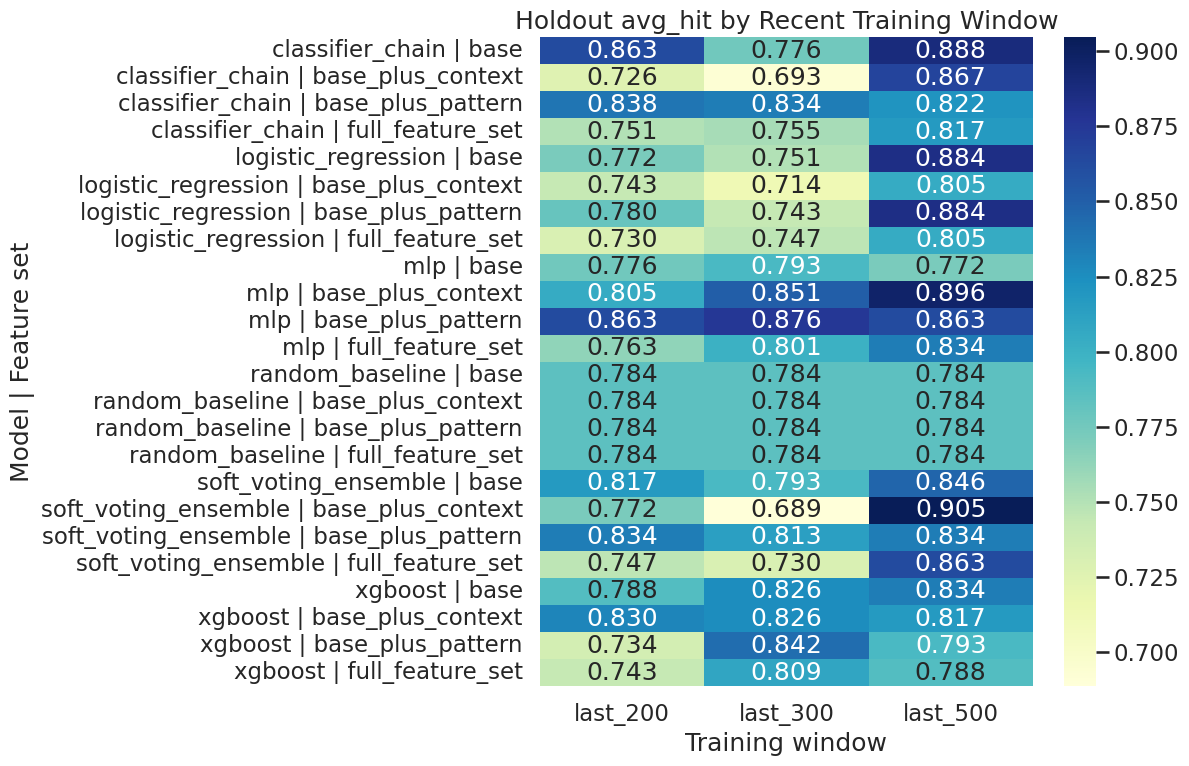

In [8]:
holdout_heatmap_source = holdout_summary.copy()
holdout_heatmap_source['row_label'] = holdout_heatmap_source['model'] + ' | ' + holdout_heatmap_source['feature_set']
holdout_heatmap = holdout_heatmap_source.pivot(index='row_label', columns='train_window_label', values='avg_hit')
fig_holdout_heatmap, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(holdout_heatmap, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax)
ax.set_title('Holdout avg_hit by Recent Training Window')
ax.set_xlabel('Training window')
ax.set_ylabel('Model | Feature set')
plt.tight_layout()
plt.show()

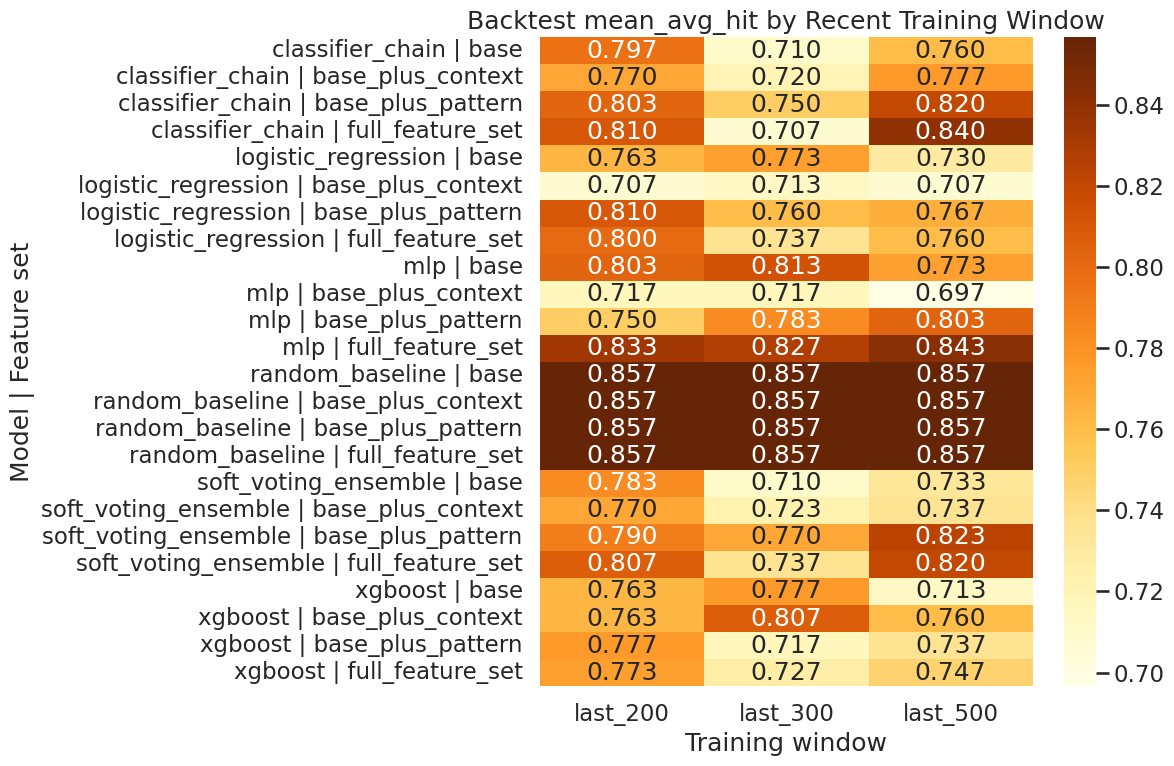

In [9]:
backtest_heatmap_source = backtest_summary.copy()
backtest_heatmap_source['row_label'] = backtest_heatmap_source['model'] + ' | ' + backtest_heatmap_source['feature_set']
backtest_heatmap = backtest_heatmap_source.pivot(index='row_label', columns='train_window_label', values='mean_avg_hit')
fig_backtest_heatmap, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(backtest_heatmap, annot=True, fmt='.3f', cmap='YlOrBr', ax=ax)
ax.set_title('Backtest mean_avg_hit by Recent Training Window')
ax.set_xlabel('Training window')
ax.set_ylabel('Model | Feature set')
plt.tight_layout()
plt.show()

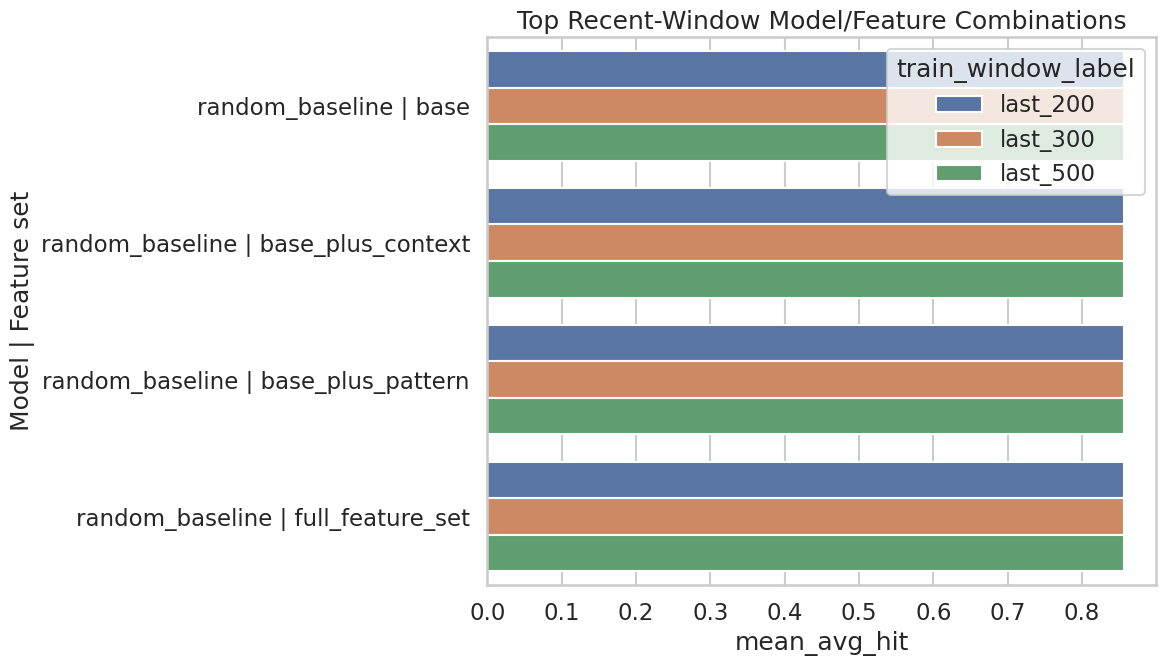

In [10]:
top_backtest = backtest_summary.head(12).copy()
top_backtest['label'] = top_backtest['model'] + ' | ' + top_backtest['feature_set']
fig_top_compare, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=top_backtest, x='mean_avg_hit', y='label', hue='train_window_label', ax=ax)
ax.set_title('Top Recent-Window Model/Feature Combinations')
ax.set_xlabel('mean_avg_hit')
ax.set_ylabel('Model | Feature set')
plt.tight_layout()
plt.show()

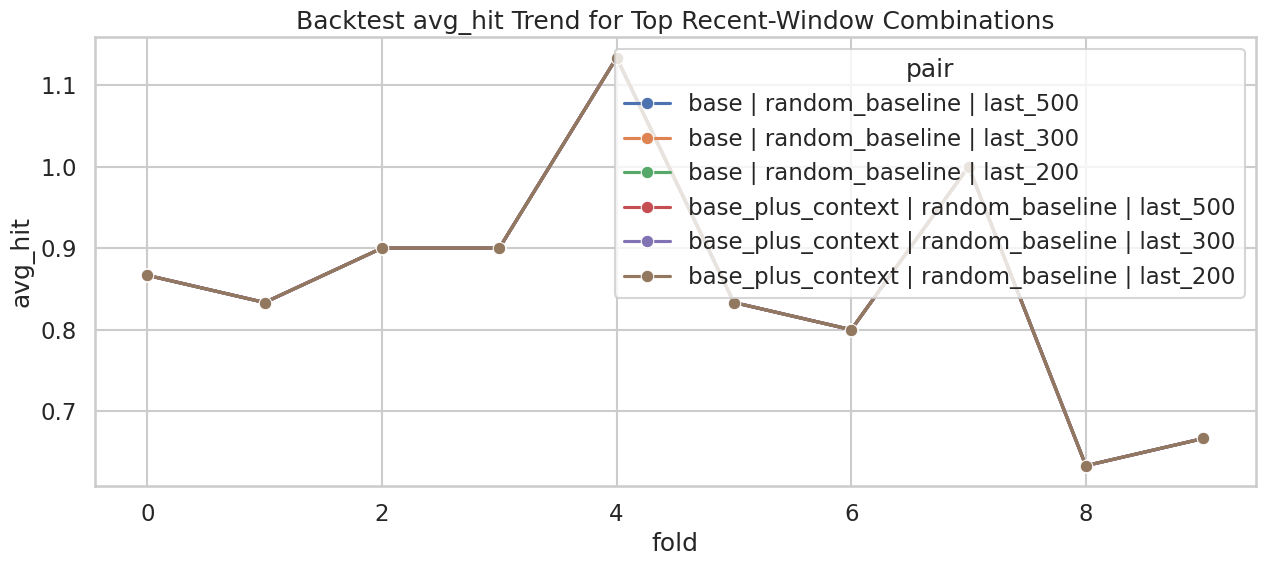

In [11]:
top_pairs = backtest_summary.head(6)[['feature_set', 'model', 'train_window_label']]
trend_df = backtest_full_results.merge(top_pairs, on=['feature_set', 'model', 'train_window_label'], how='inner')
trend_df['pair'] = trend_df['feature_set'] + ' | ' + trend_df['model'] + ' | ' + trend_df['train_window_label']
fig_backtest_trend, ax = plt.subplots(figsize=(13, 6))
sns.lineplot(data=trend_df, x='fold', y='avg_hit', hue='pair', marker='o', ax=ax)
ax.set_title('Backtest avg_hit Trend for Top Recent-Window Combinations')
plt.tight_layout()
plt.show()

## Interpretation Notes

In [12]:
display_cols_holdout = ['feature_set', 'model', 'train_window_label', 'avg_hit', 'precision_at_6', 'brier_score']
display_cols_backtest = ['feature_set', 'model', 'train_window_label', 'mean_avg_hit', 'mean_precision_at_6', 'mean_brier_score']
holdout_summary[display_cols_holdout].head(12), backtest_summary[display_cols_backtest].head(12)

(          feature_set                 model train_window_label   avg_hit  \
 0   base_plus_context  soft_voting_ensemble           last_500  0.904564   
 1   base_plus_context                   mlp           last_500  0.896266   
 2                base      classifier_chain           last_500  0.887967   
 3                base   logistic_regression           last_500  0.883817   
 4   base_plus_pattern   logistic_regression           last_500  0.883817   
 5   base_plus_pattern                   mlp           last_300  0.875519   
 6   base_plus_context      classifier_chain           last_500  0.867220   
 7                base      classifier_chain           last_200  0.863071   
 8   base_plus_pattern                   mlp           last_500  0.863071   
 9   base_plus_pattern                   mlp           last_200  0.863071   
 10   full_feature_set  soft_voting_ensemble           last_500  0.863071   
 11  base_plus_context                   mlp           last_300  0.850622   

Use the results conservatively:

- if `last_300` or `last_200` wins, older draws are likely acting more like noise than signal
- if `base_plus_pattern` gains more from short windows than `base`, internal draw-pattern features may be more local/regime-sensitive than simple frequency+gap
- if performance changes only on holdout but not on rolling backtest, prefer the backtest conclusion

## Report Export

In [13]:
save_report_figure(fig_holdout_heatmap, 'fig_36_recent_window_holdout_heatmap.png')
save_report_figure(fig_backtest_heatmap, 'fig_37_recent_window_backtest_heatmap.png')
save_report_figure(fig_top_compare, 'fig_38_recent_window_top_comparison.png')
save_report_figure(fig_backtest_trend, 'fig_39_recent_window_backtest_trend.png')

save_report_table(holdout_summary, 'table_29_recent_window_holdout_summary.csv')
save_report_table(backtest_summary, 'table_30_recent_window_backtest_summary.csv')
save_report_table(backtest_full_results, 'table_31_recent_window_full_results.csv')
print('Saved recent-window modeling report artifacts.')

Saved recent-window modeling report artifacts.
